# Bradley-Terry Model Convergence Analysis

This notebook analyzes the convergence of Bradley-Terry weights for different Qwen models as more data (templates) are added.

In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add src to path to import local modules
sys.path.append(os.path.abspath('src'))

from pref_models import fit_bradley_terry
from plot_utils import calculate_bt_convergence, color_map, get_model_name

# Set plot style
sns.set_theme(style="whitegrid")

In [8]:
# Define experiments to analyze
experiments = [
    'qwen0_5_all_metrics',
    'qwen0_5I_all_metrics',
    'qwen7_all_metrics',
    'qwen7I_all_metrics',
    'qwen32_all_metrics',
    'qwen32I_all_metrics',
    'qwen72_all_metrics',
    'qwen72I_all_metrics'
]

In [10]:
# Run analysis for all experiments
results = {}

for exp in experiments:
    print(f"Processing {exp}...")
    df_convergence = calculate_bt_convergence(exp)
    if df_convergence is not None:
        results[exp] = df_convergence
    print(f"Finished {exp}")


Processing qwen0_5_all_metrics...
Finished qwen0_5_all_metrics
Processing qwen0_5I_all_metrics...
Finished qwen0_5I_all_metrics
Processing qwen7_all_metrics...
Finished qwen7_all_metrics
Processing qwen7I_all_metrics...
Finished qwen7I_all_metrics
Processing qwen32_all_metrics...
Finished qwen32_all_metrics
Processing qwen32I_all_metrics...
Finished qwen32I_all_metrics
Processing qwen72_all_metrics...
Finished qwen72_all_metrics
Processing qwen72I_all_metrics...
Finished qwen72I_all_metrics


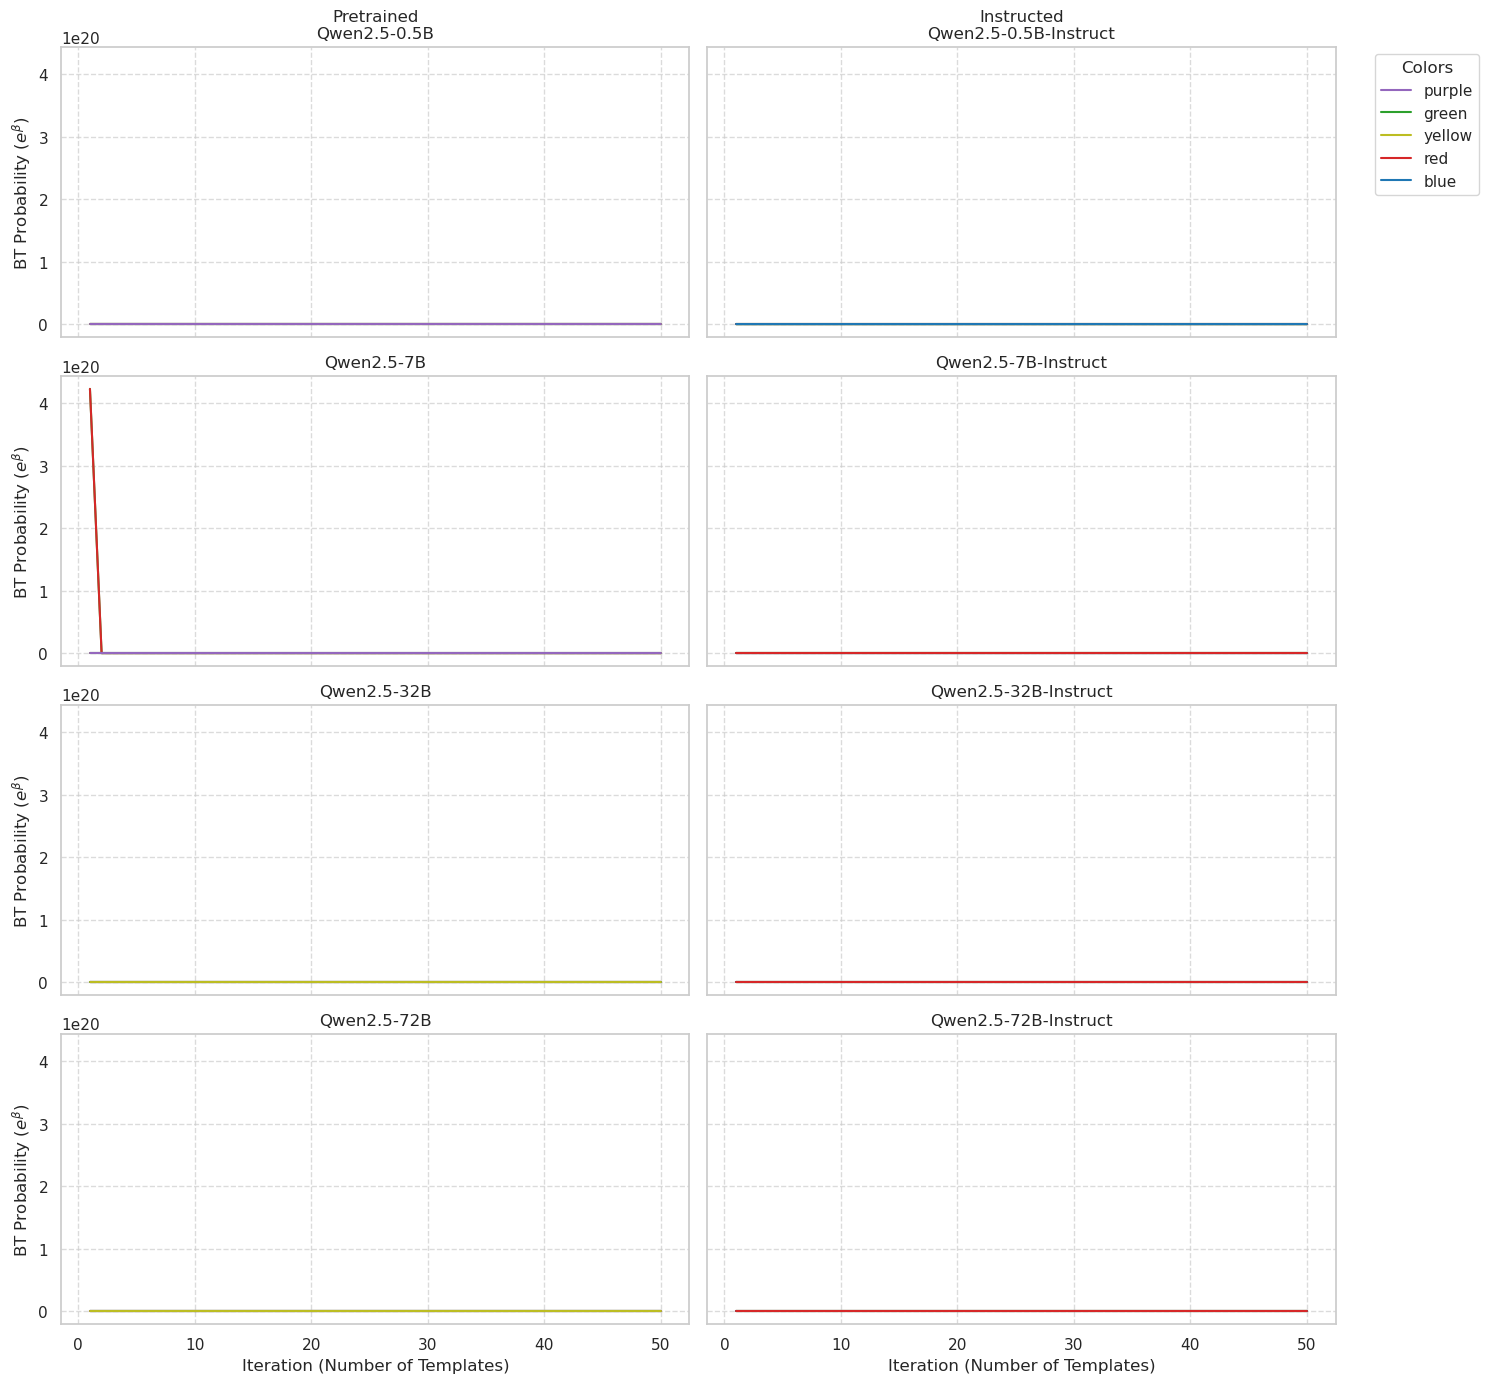

In [12]:


# Identify sizes present in results
sizes = set()
for exp in results.keys():
    name = exp.replace('qwen', '').replace('_all_metrics', '')
    if name.endswith('I'):
        name = name[:-1]
    sizes.add(name)

def size_sorter(s):
    try:
        return float(s.replace('_', '.'))
    except ValueError:
        return 0.0

sorted_sizes = sorted(list(sizes), key=size_sorter)
n_rows = len(sorted_sizes)
n_cols = 2 # Left: Pretrained, Right: Instructed

if n_rows > 0:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3.5 * n_rows), sharex=True, sharey=True, squeeze=False)

    for i, size in enumerate(sorted_sizes):
        # Construct experiment names for this size
        # Expected format: qwen{size}{I}_all_metrics
        base_exp = f"qwen{size}_all_metrics"
        instruct_exp = f"qwen{size}I_all_metrics"
        
        row_exps = [base_exp, instruct_exp]
        
        for j, exp in enumerate(row_exps):
            ax = axes[i, j]
            
            # Label columns
            if i == 0:
                ax.set_title(f"{'Pretrained' if j == 0 else 'Instructed'}\n{get_model_name(exp)}")
            else:
                ax.set_title(get_model_name(exp))

            if exp in results:
                df = results[exp]
                color_cols = [c for c in df.columns if c not in ['iteration', 'num_templates']]
                
                for color in color_cols:
                    plot_color = color_map.get(color, color)
                    ax.plot(df['iteration'], df[color], label=color, color=plot_color)
                
                ax.grid(True, linestyle='--', alpha=0.7)
                
                # Add Legend to the top-right plot
                if i == 0 and j == 1:
                    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Colors")
            else:
                ax.text(0.5, 0.5, 'Not Available', ha='center', va='center')

            # Set labels
            if j == 0:
                ax.set_ylabel('BT Probability ($e^\\beta$)')
            if i == n_rows - 1:
                ax.set_xlabel('Iteration (Number of Templates)')

    # Overall title
    # fig.suptitle('Bradley-Terry Probability Convergence', fontsize=16) 
    
    plt.tight_layout()
    plt.savefig('bt_convergence_history_combined.pdf', format='pdf', bbox_inches='tight')
    plt.show()
else:
    print("No results found.")

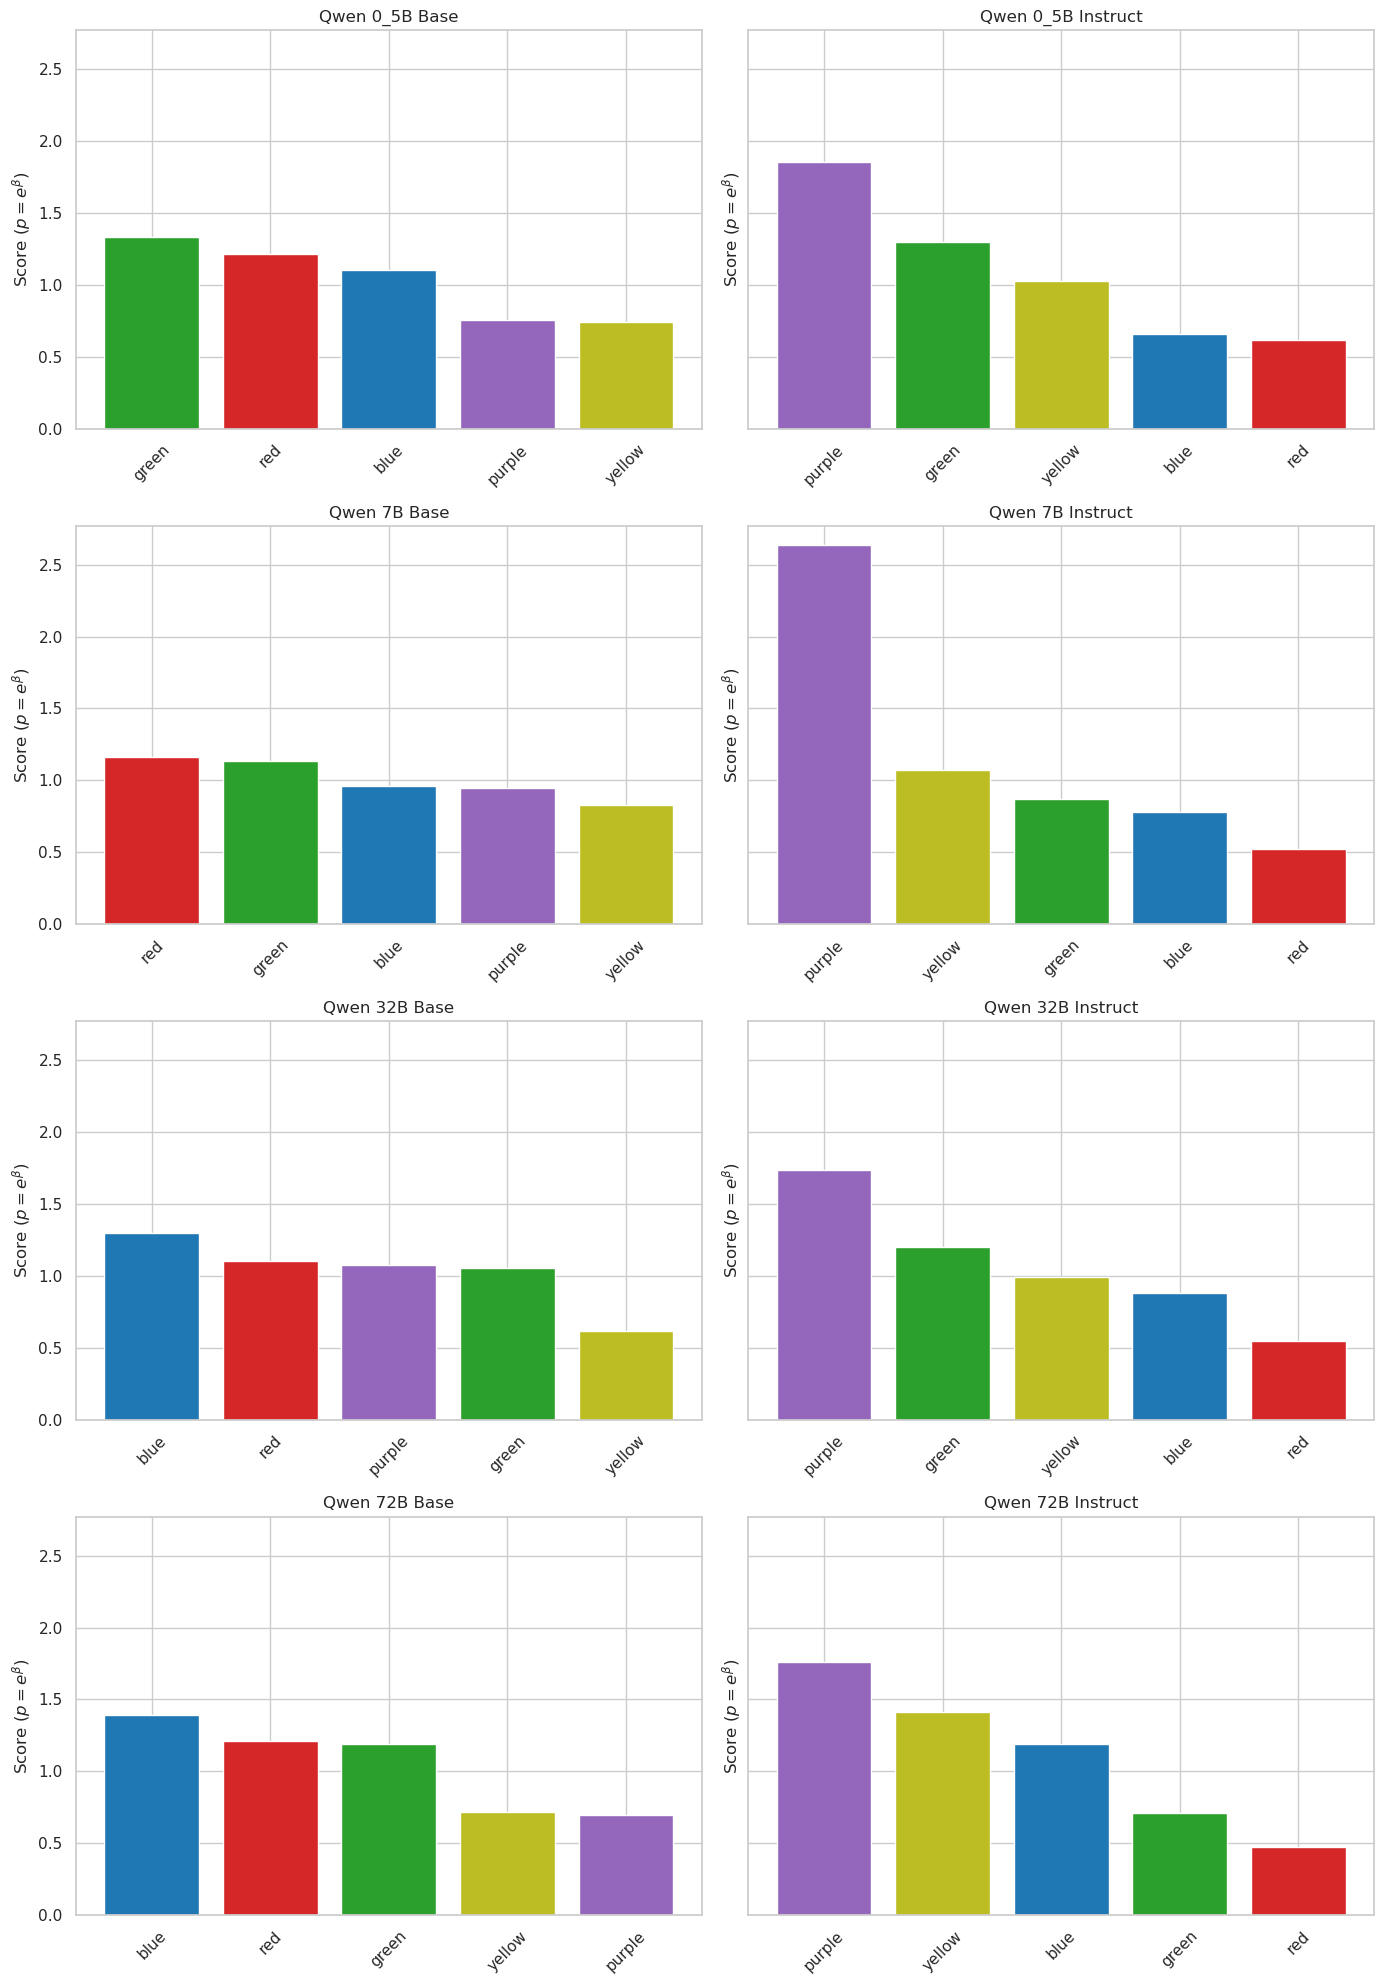

In [13]:
# Analyze final probabilities (p = e^beta)
# Parse experiments to organize by size and type
model_data = {}

for exp in experiments:
    if exp not in results:
        continue
        
    # Extract size and type
    # Expected format: qwen{SIZE}{I}_all_metrics
    # Remove prefix and suffix
    inner = exp.replace('qwen', '').replace('_all_metrics', '')
    
    is_instruct = inner.endswith('I')
    if is_instruct:
        size = inner[:-1]
    else:
        size = inner
        
    if size not in model_data:
        model_data[size] = {'Base': None, 'Instruct': None}
        
    model_data[size]['Instruct' if is_instruct else 'Base'] = results[exp]

# Sort sizes (0_5, 7, 32, 72)
def parse_size(s):
    try:
        return float(s.replace('_', '.'))
    except ValueError:
        return 0.0 # Fallback

sorted_sizes = sorted(model_data.keys(), key=parse_size)
n_sizes = len(sorted_sizes)

if n_sizes > 0:
    # squeeze=False ensures axes is always a 2D array
    fig, axes = plt.subplots(n_sizes, 2, figsize=(14, 5 * n_sizes), sharey=True, squeeze=False)
    
    for i, size in enumerate(sorted_sizes):
        # Row i
        # Left: Base, Right: Instruct
        types = ['Base', 'Instruct']
        
        for j, type_name in enumerate(types):
            ax = axes[i, j]
            
            df = model_data[size][type_name]
            if df is not None:
                # Get final row
                final_row = df.iloc[-1]
                # Filter for color columns
                colors = [c for c in df.columns if c not in ['iteration', 'num_templates']]
                
                # Create a series for plotting
                final_probs = final_row[colors].sort_values(ascending=False)
                
                # Plot bar chart
                bars = ax.bar(final_probs.index, final_probs.values, color=[color_map.get(c, 'gray') for c in final_probs.index])
                
                ax.set_title(f'Qwen {size}B {type_name}')
                ax.set_ylabel('Score ($p=e^\\beta$)')
                ax.tick_params(axis='x', rotation=45)
            else:
                ax.text(0.5, 0.5, 'Not Available', ha='center', va='center')
                ax.set_title(f'Qwen {size}B {type_name}')
                ax.axis('off')
                
    plt.tight_layout()
    plt.savefig('bt_final_probabilities.pdf', format='pdf', bbox_inches='tight')
    plt.show()
else:
    print("No relevant experiments found in results.")

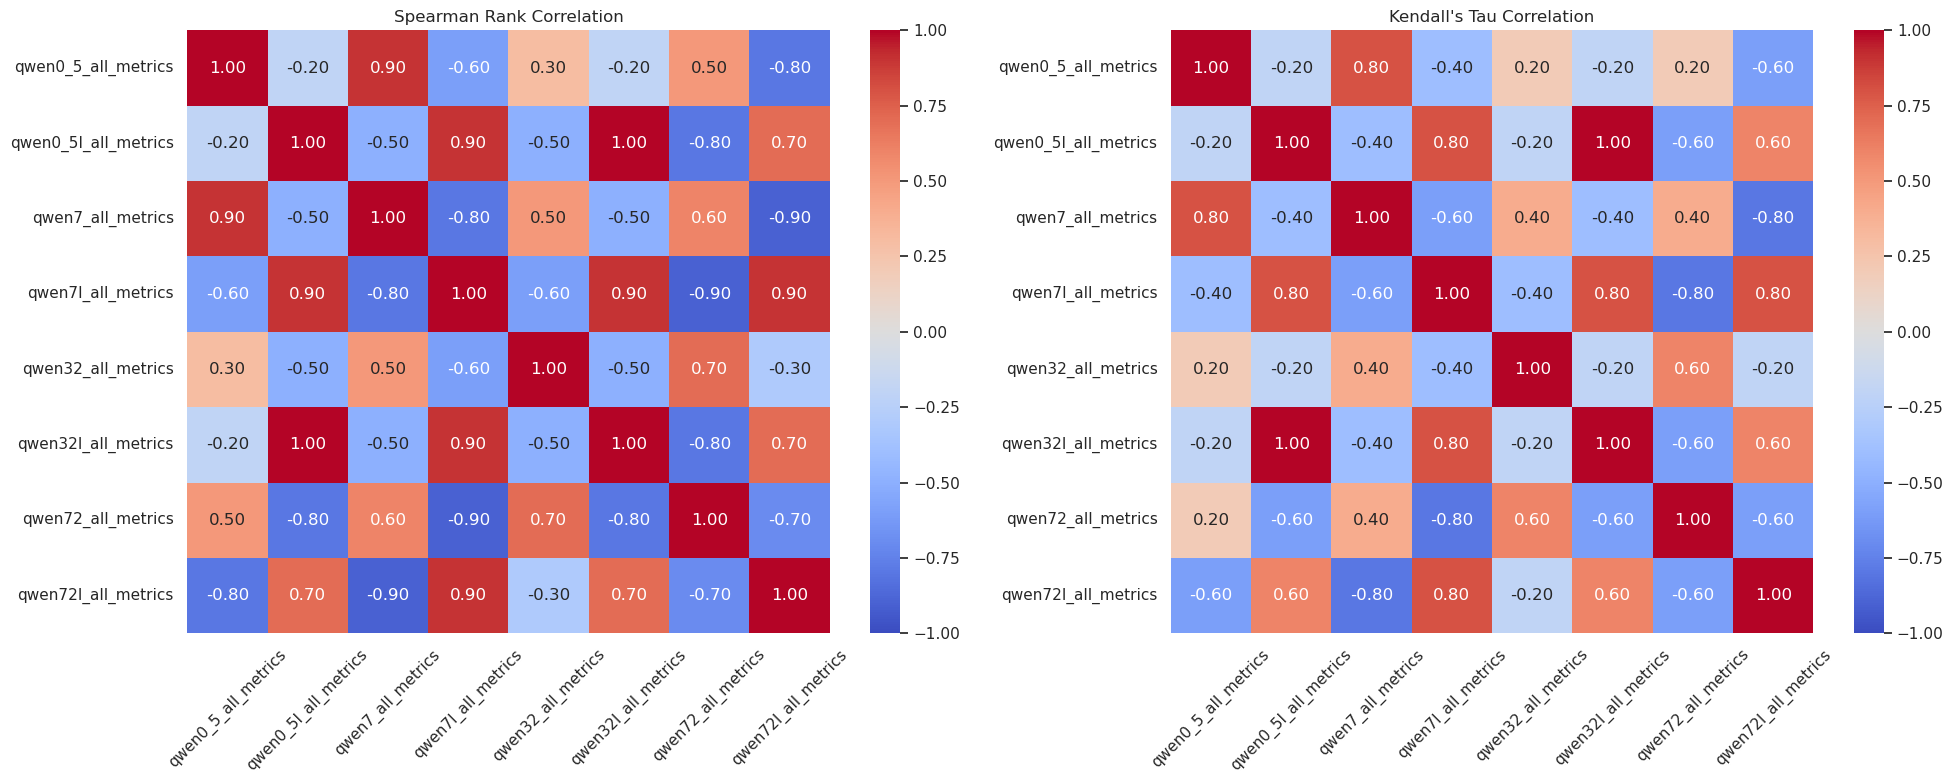

In [14]:
# Correlation Analysis Heatmaps
import scipy.stats as stats

# 1. Consolidate final weights into a single DataFrame
# Rows: Colors, Columns: Experiment Names
final_scores_dict = {}

for exp, df in results.items():
    # Colors columns are all columns except 'iteration' and 'num_templates'
    color_cols = [c for c in df.columns if c not in ['iteration', 'num_templates']]
    if not color_cols:
        continue
        
    last_row = df.iloc[-1]
    final_scores_dict[exp] = last_row[color_cols]

if not final_scores_dict:
    print("No results to correlate.")
else:
    scores_df = pd.DataFrame(final_scores_dict)
    
    # 2. Calculate Correlation Matrices
    spearman_corr = scores_df.corr(method='spearman')
    kendall_corr = scores_df.corr(method='kendall')

    # 3. Plot Heatmaps
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # Spearman Heatmap
    sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0], vmin=-1, vmax=1)
    axes[0].set_title("Spearman Rank Correlation")
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].tick_params(axis='y', rotation=0)

    # Kendall's Tau Heatmap
    sns.heatmap(kendall_corr, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1], vmin=-1, vmax=1)
    axes[1].set_title("Kendall's Tau Correlation")
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].tick_params(axis='y', rotation=0)

    plt.tight_layout()
    plt.savefig('bt_correlation_heatmaps.pdf', format='pdf', bbox_inches='tight')
    plt.show()

<Figure size 1000x600 with 0 Axes>

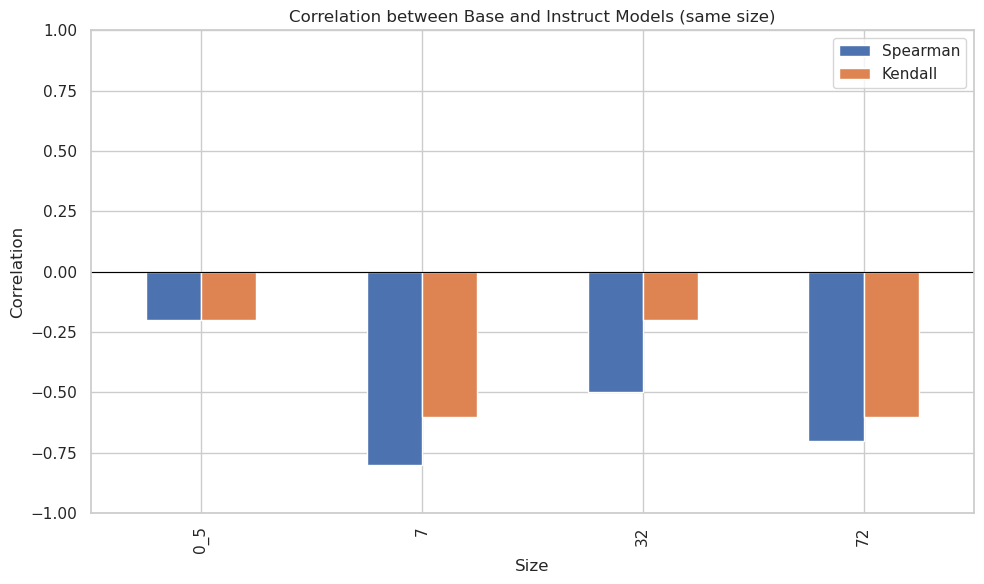

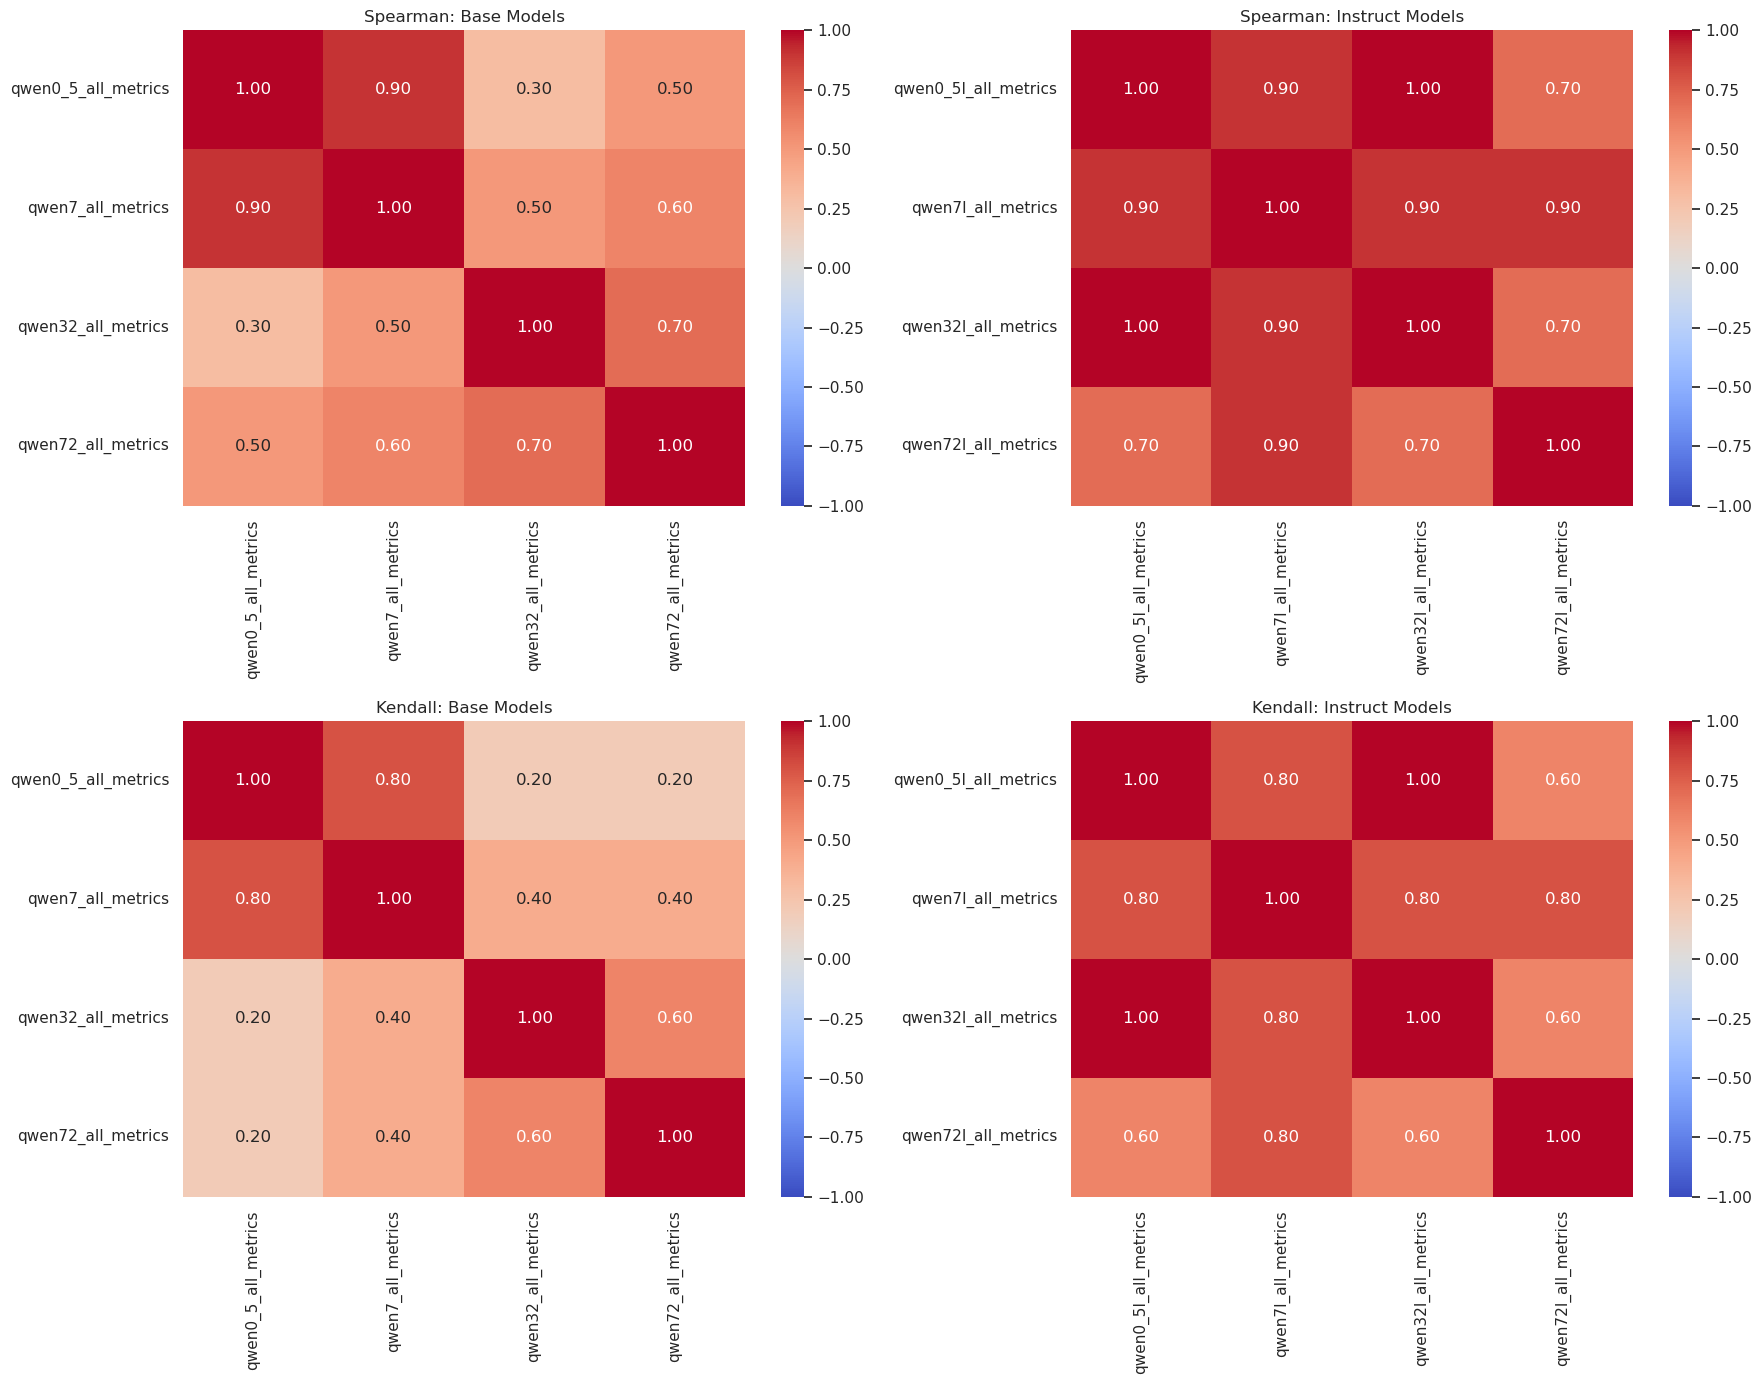

In [15]:
# Base vs. Instruct Correlation Analysis

if 'scores_df' in locals():
    # Identify Base and Instruct models
    base_models = []
    instruct_models = []

    for col in scores_df.columns:
        # Extract inner part to check for 'I'
        inner = col.replace('qwen', '').replace('_all_metrics', '')
        if inner.endswith('I'):
            instruct_models.append(col)
        else:
            base_models.append(col)
            
    # 1. Pairwise Correlation (Base vs Instruct for same size)
    pair_correlations = []
    
    for base in base_models:
        # Construct expected instruct name
        # base: qwenX_all_metrics -> size: X
        size = base.replace('qwen', '').replace('_all_metrics', '')
        instruct = f'qwen{size}I_all_metrics'
        
        if instruct in scores_df.columns:
            s_corr = scores_df[base].corr(scores_df[instruct], method='spearman')
            k_corr = scores_df[base].corr(scores_df[instruct], method='kendall')
            pair_correlations.append({
                'Size': size,
                'Spearman': s_corr,
                'Kendall': k_corr
            })
            
    if pair_correlations:
        pair_corr_df = pd.DataFrame(pair_correlations).set_index('Size')
        
        # Sort by size value
        def parse_size_val(s):
            try:
                return float(s.replace('_', '.'))
            except:
                return 0
        
        pair_corr_df = pair_corr_df.sort_index(key=lambda x: x.map(parse_size_val))

        # Plot pair correlations
        plt.figure(figsize=(10, 6))
        pair_corr_df.plot(kind='bar', figsize=(10, 6))
        plt.title('Correlation between Base and Instruct Models (same size)')
        plt.ylabel('Correlation')
        plt.ylim(-1, 1)
        plt.axhline(0, color='black', linewidth=0.8)
        plt.legend()
        plt.tight_layout()
        plt.savefig('bt_base_vs_instruct_correlation.pdf', format='pdf', bbox_inches='tight')
        plt.show()
    else:
        print("No matching Base-Instruct pairs found.")

    # 2. Internal Group Correlations (Base vs Base, Instruct vs Instruct)
    if base_models and instruct_models:
        # Calculate full correlation matrices
        spearman_full = scores_df.corr(method='spearman')
        kendall_full = scores_df.corr(method='kendall')
        
        valid_base = [m for m in base_models if m in spearman_full.index]
        valid_instruct = [m for m in instruct_models if m in spearman_full.columns]

        # Create 2x2 plot for (Base, Instruct) x (Spearman, Kendall)
        fig, axes = plt.subplots(2, 2, figsize=(18, 14))
        
        # Spearman - Base
        sns.heatmap(spearman_full.loc[valid_base, valid_base], annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0,0], vmin=-1, vmax=1)
        axes[0,0].set_title("Spearman: Base Models")
        
        # Spearman - Instruct
        sns.heatmap(spearman_full.loc[valid_instruct, valid_instruct], annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0,1], vmin=-1, vmax=1)
        axes[0,1].set_title("Spearman: Instruct Models")

        # Kendall - Base
        sns.heatmap(kendall_full.loc[valid_base, valid_base], annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1,0], vmin=-1, vmax=1)
        axes[1,0].set_title("Kendall: Base Models")
        
        # Kendall - Instruct
        sns.heatmap(kendall_full.loc[valid_instruct, valid_instruct], annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1,1], vmin=-1, vmax=1)
        axes[1,1].set_title("Kendall: Instruct Models")
        
        plt.tight_layout()
        plt.savefig('bt_group_correlations.pdf', format='pdf', bbox_inches='tight')
        plt.show()
    else:
        print("Insufficient models for group comparison.")
else:
    print("scores_df not found. Run the previous cell first.")

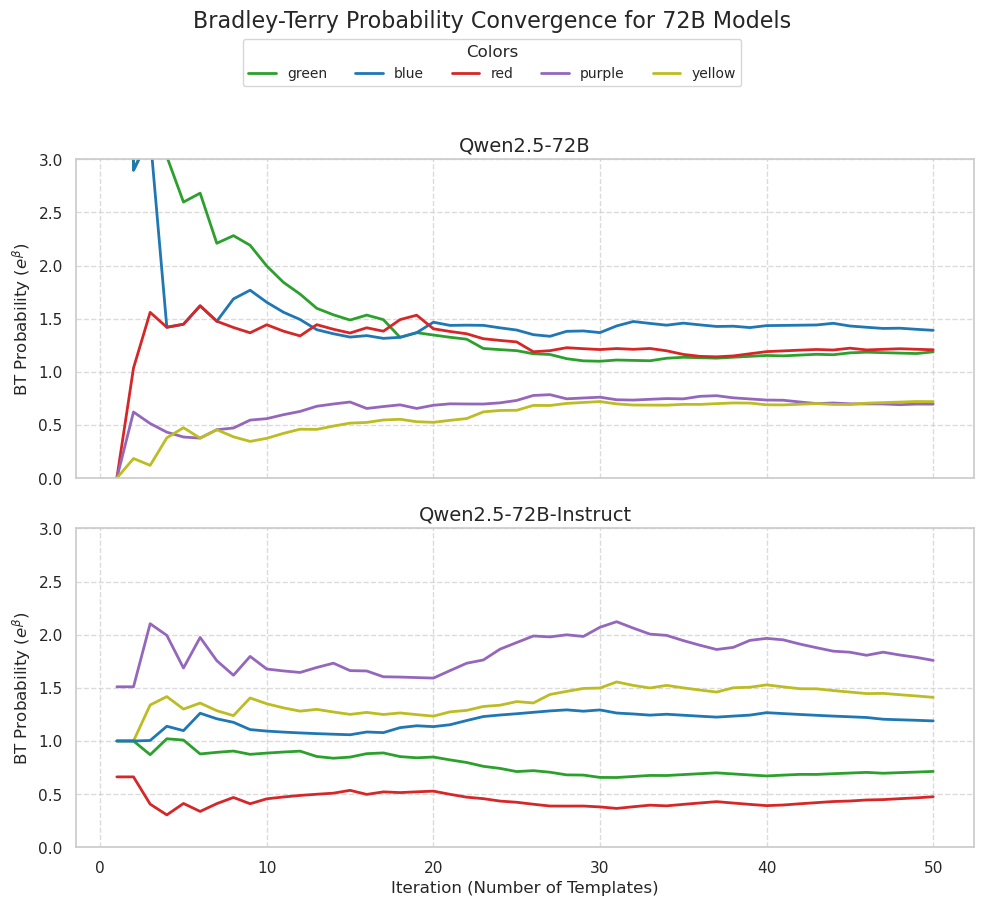

In [30]:
# Convergence Analysis for 72B Models (Base vs Instruct)

# Filter for 72B experiments
exp_72_base = 'qwen72_all_metrics'
exp_72_instruct = 'qwen72I_all_metrics'
exps_to_plot_72 = [exp_72_base, exp_72_instruct]

# Create figure with 2 subplots (vertical)
# Increase top margin to make room for legend
fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=True, sharey=True)

# Store handles and labels for the legend
handles, labels = [], []

for i, exp in enumerate(exps_to_plot_72):
    ax = axes[i]
    model_label = get_model_name(exp)
    
    if exp in results:
        df = results[exp]
        colors = [c for c in df.columns if c not in ['iteration', 'num_templates']]
        
        for color in colors:
            plot_color = color_map.get(color, color)
            line, = ax.plot(df['iteration'], df[color], label=color, color=plot_color, linewidth=2)
            
            # Collect handles/labels specifically from the first plot for the shared legend
            if i == 0:
                handles.append(line)
                labels.append(color)
            
        ax.set_title(model_label, fontsize=14)
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.set_ylabel('BT Probability ($e^\\beta$)', fontsize=12)
        ax.set_ylim(0, 3)
        
    else:
        ax.text(0.5, 0.5, f'Data for {exp} not found', ha='center', va='center')
        ax.set_title(model_label)

axes[-1].set_xlabel('Iteration (Number of Templates)', fontsize=12)

# Add shared legend at the top
# Calculate number of columns for legend (e.g., 5 cols for ~10 items)
n_cols_legend = min(len(labels), 6) 
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98), 
           ncol=n_cols_legend, title="Colors", fontsize=10, title_fontsize=12)
fig.suptitle('Bradley-Terry Probability Convergence for 72B Models', fontsize=16, y=1.005)
# Adjust layout to accommodate legend
plt.tight_layout(rect=[0, 0, 1, 0.93]) 
plt.savefig('figures/bt_convergence_72B.pdf', format='pdf', bbox_inches='tight')
plt.savefig('figures/bt_convergence_72B.png', format='png', bbox_inches='tight')
plt.show()

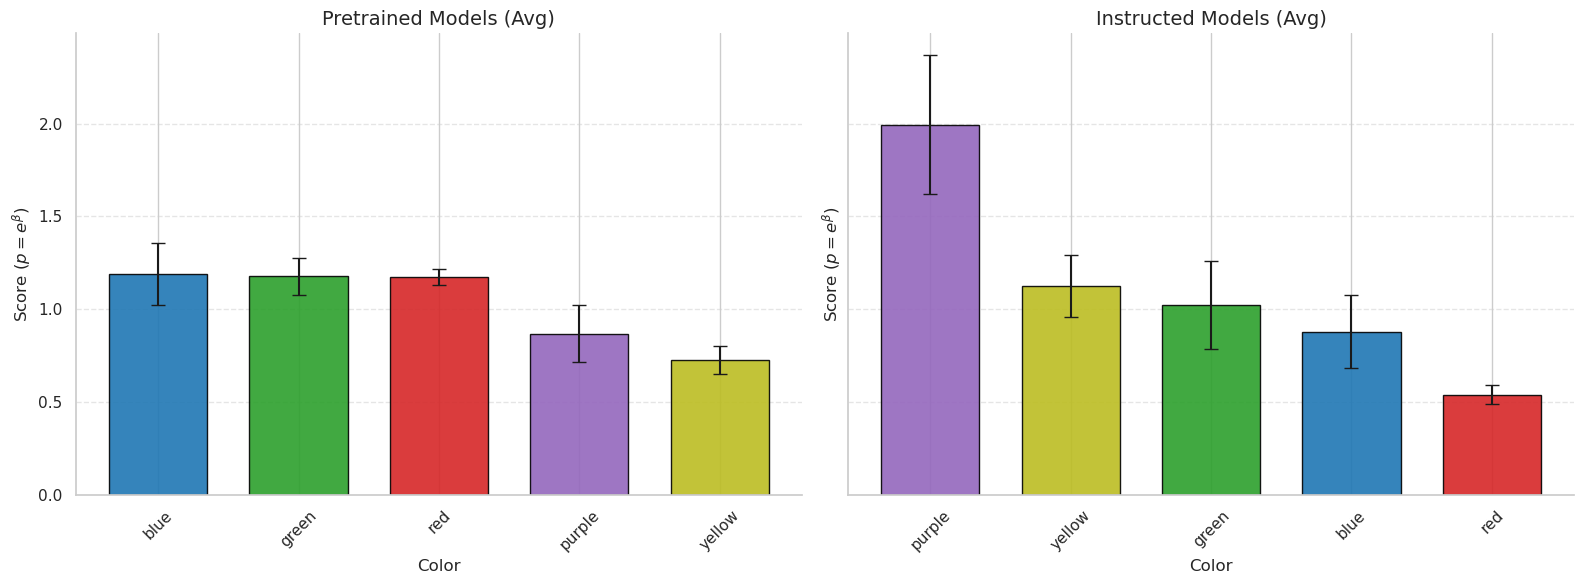

In [31]:
# Aggregated Final Weights Analysis (Separated by Base/Instruct)

# Helper function to get aggregated stats
def get_aggregated_stats(result_subset):
    color_scores = {}
    for exp, df in result_subset.items():
        colors = [c for c in df.columns if c not in ['iteration', 'num_templates']]
        last_row = df.iloc[-1]
        for color in colors:
            if color not in color_scores:
                color_scores[color] = []
            color_scores[color].append(last_row[color])
            
    summary_data = []
    if color_scores:
        for color, scores in color_scores.items():
            summary_data.append({
                'Color': color,
                'Mean': np.mean(scores),
                'Std': np.std(scores)
            })
        return pd.DataFrame(summary_data).sort_values('Mean', ascending=False)
    return pd.DataFrame()

# Separate results into Base and Instruct
results_base = {}
results_instruct = {}

for exp, df in results.items():
    # Helper logic to determine type
    clean_name = exp.replace('qwen', '').replace('_all_metrics', '')
    if clean_name.endswith('I'):
        results_instruct[exp] = df
    else:
        results_base[exp] = df

# Compute stats
df_base = get_aggregated_stats(results_base)
df_instruct = get_aggregated_stats(results_instruct)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Helper for single subplot
def plot_agg_bars(ax, df, title):
    if not df.empty:
        bar_colors = [color_map.get(c, 'gray') for c in df['Color']]
        ax.bar(df['Color'], df['Mean'], yerr=df['Std'], 
               capsize=5, color=bar_colors, alpha=0.9, edgecolor='black', width=0.7)
        ax.set_title(title, fontsize=14)
        ax.set_ylabel('Score ($p=e^\\beta$)', fontsize=12)
        ax.set_xlabel('Color', fontsize=12)
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        # Rotate x labels
        ax.tick_params(axis='x', rotation=45)
    else:
        ax.text(0.5, 0.5, "No Data", ha='center')
        ax.set_title(title)

# Plot Left: Pretrained
plot_agg_bars(axes[0], df_base, 'Pretrained Models (Avg)')

# Plot Right: Instructed
plot_agg_bars(axes[1], df_instruct, 'Instructed Models (Avg)')

# Remove top and right spines for cleaner look
sns.despine()

plt.tight_layout()
plt.savefig('figures/bt_aggregated_weights_split.pdf', format='pdf', bbox_inches='tight')
plt.savefig('figures/bt_aggregated_weights_split.png', format='png', bbox_inches='tight')
plt.show()

In [6]:
from prompts import stocks_names_dict

# Process qwen7_stocks experiment
exp_name = "qwen7_stocks"
print(f"Processing {exp_name}...")
df_convergence_stocks = calculate_bt_convergence(exp_name)
print(f"Finished {exp_name}")

Processing qwen7_stocks...
Finished qwen7_stocks


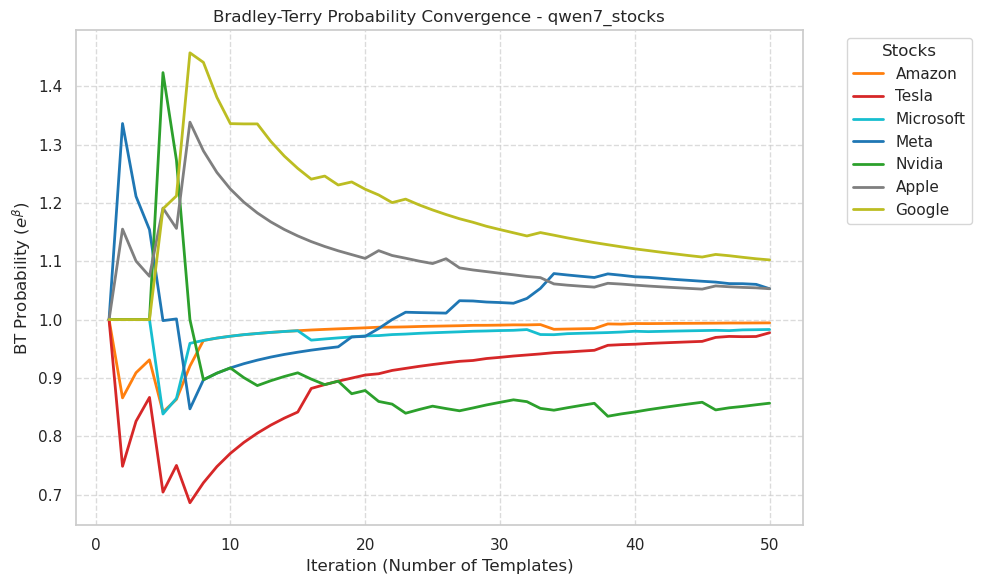

In [7]:
if df_convergence_stocks is not None:
    plt.figure(figsize=(10, 6))
    
    color_cols = [c for c in df_convergence_stocks.columns if c not in ['iteration', 'num_templates']]
    
    for stock_name in color_cols:
        # Get color name from stock name (e.g. Apple -> Gray)
        color_name = stocks_names_dict.get(stock_name, 'black').lower()
        # Get hex color from color map
        plot_color = color_map.get(color_name, 'black')
        
        plt.plot(df_convergence_stocks['iteration'], df_convergence_stocks[stock_name], label=stock_name, color=plot_color, linewidth=2)
    
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Stocks")
    plt.title(f"Bradley-Terry Probability Convergence - {exp_name}")
    plt.ylabel('BT Probability ($e^\\beta$)')
    plt.xlabel('Iteration (Number of Templates)')
    plt.tight_layout()
    plt.show()
else:
    print("No results found for stocks experiment.")

In [13]:
from prompts import stocks_names_dict

# Process qwen7_stocks experiment
exp_name = "qwen7I_stocks"
print(f"Processing {exp_name}...")
df_convergence_stocks = calculate_bt_convergence(exp_name)
print(f"Finished {exp_name}")

Processing qwen7I_stocks...
Finished qwen7I_stocks


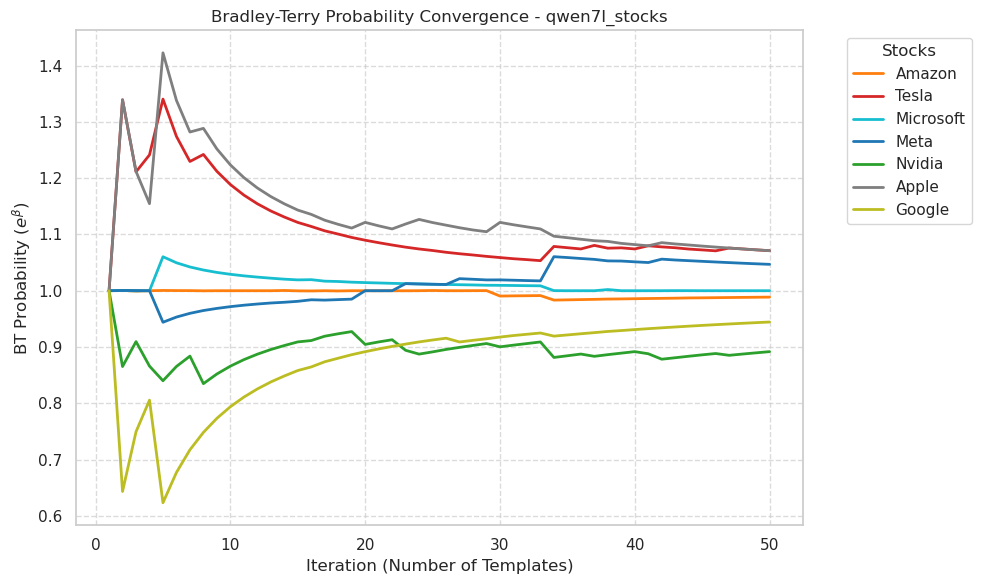

In [14]:
if df_convergence_stocks is not None:
    plt.figure(figsize=(10, 6))
    
    color_cols = [c for c in df_convergence_stocks.columns if c not in ['iteration', 'num_templates']]
    
    for stock_name in color_cols:
        # Get color name from stock name (e.g. Apple -> Gray)
        color_name = stocks_names_dict.get(stock_name, 'black').lower()
        # Get hex color from color map
        plot_color = color_map.get(color_name, 'black')
        
        plt.plot(df_convergence_stocks['iteration'], df_convergence_stocks[stock_name], label=stock_name, color=plot_color, linewidth=2)
    
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Stocks")
    plt.title(f"Bradley-Terry Probability Convergence - {exp_name}")
    plt.ylabel('BT Probability ($e^\\beta$)')
    plt.xlabel('Iteration (Number of Templates)')
    plt.tight_layout()
    plt.show()
else:
    print("No results found for stocks experiment.")

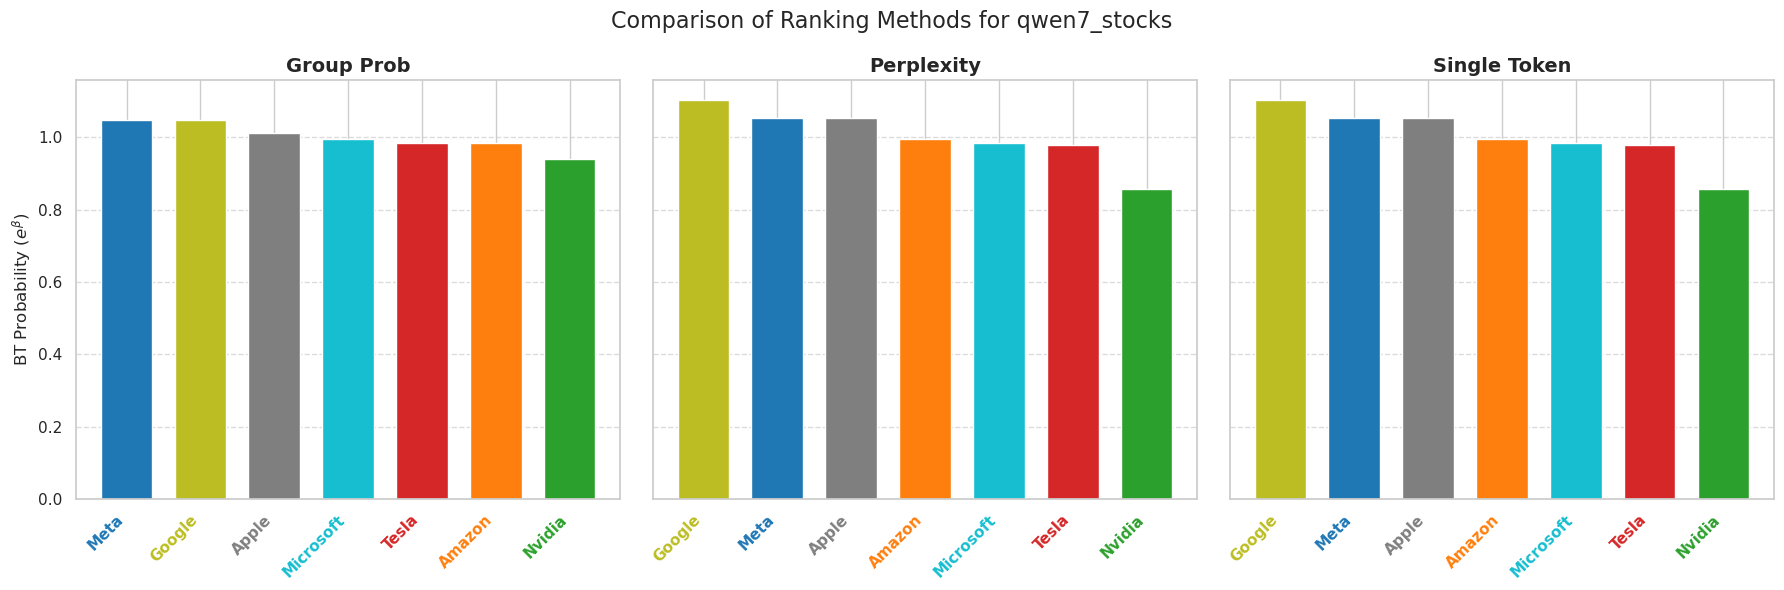

In [11]:
# Method Comparison for qwen7_stocks (Independent Sorting)
exp_name = 'qwen7_stocks'
methods = ['group', 'ppl', 'single']
method_labels = {'group': 'Group Prob', 'ppl': 'Perplexity', 'single': 'Single Token'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, method in enumerate(methods):
    ax = axes[i]
    file_path = os.path.join('experiments', exp_name, f'rankings_{method}.csv')
    
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        df['Probability'] = np.exp(df['BT_Score'])
        # Sort by values for this specific method
        df = df.sort_values('Probability', ascending=False)
        
        # Map colors
        colors = []
        for stock in df['Color']:
            c_name = stocks_names_dict.get(stock, 'black').lower()
            colors.append(color_map.get(c_name, 'gray'))
            
        # Plot
        bars = ax.bar(df['Color'], df['Probability'], color=colors, width=0.7)
        
        ax.set_title(method_labels[method], fontsize=14, fontweight='bold')
        ax.set_xlabel('')
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        
        # Color tick labels
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
        for xtick, stock in zip(ax.get_xticklabels(), df['Color']):
             c_name = stocks_names_dict.get(stock, 'black').lower()
             xtick.set_color(color_map.get(c_name, 'black'))
             xtick.set_fontweight('bold')
            
    else:
        ax.text(0.5, 0.5, "File not found", ha='center', va='center')
        ax.set_title(method_labels[method])

axes[0].set_ylabel('BT Probability ($e^\\beta$)', fontsize=12)
plt.suptitle(f'Comparison of Ranking Methods for {exp_name}', fontsize=16)
plt.tight_layout()
plt.show()

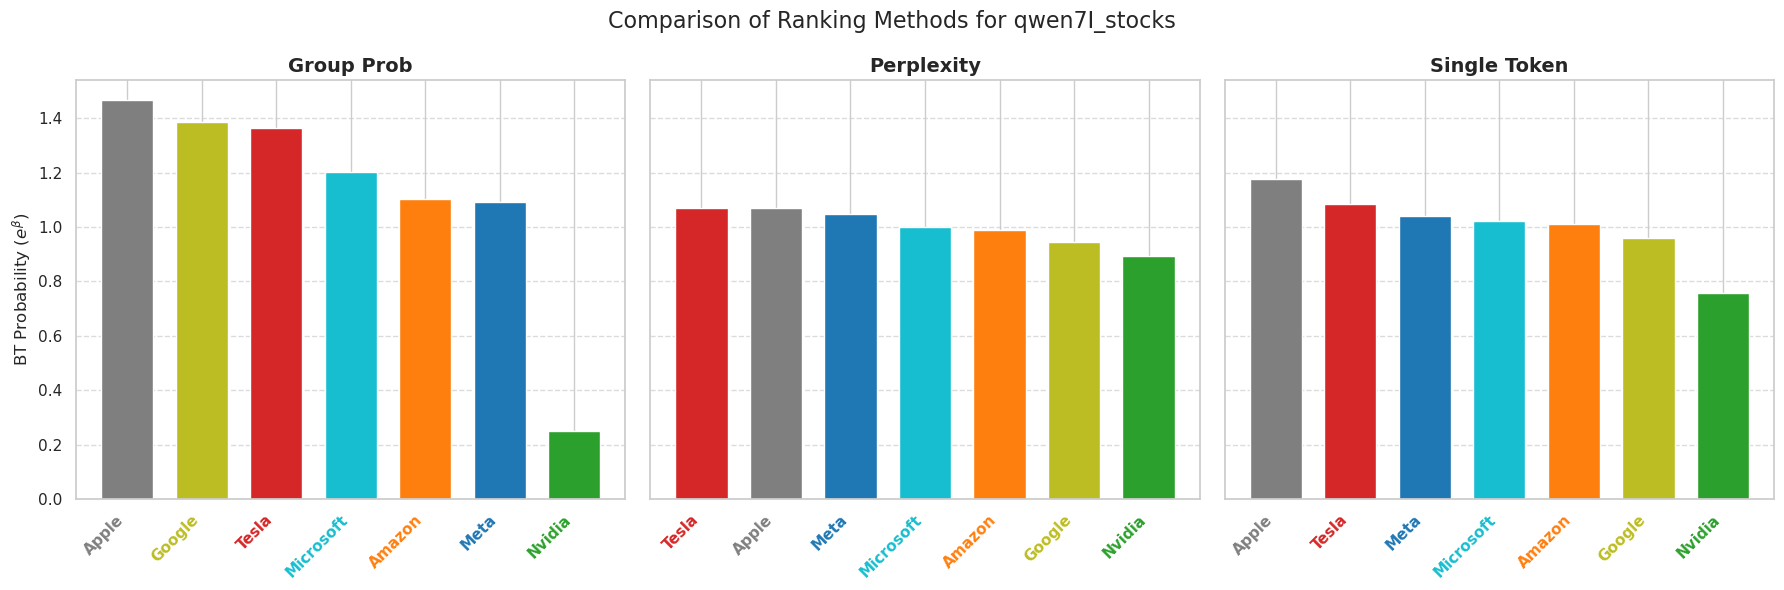

In [12]:
# Method Comparison for qwen7_stocks (Independent Sorting)
exp_name = 'qwen7I_stocks'
methods = ['group', 'ppl', 'single']
method_labels = {'group': 'Group Prob', 'ppl': 'Perplexity', 'single': 'Single Token'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, method in enumerate(methods):
    ax = axes[i]
    file_path = os.path.join('experiments', exp_name, f'rankings_{method}.csv')
    
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        df['Probability'] = np.exp(df['BT_Score'])
        # Sort by values for this specific method
        df = df.sort_values('Probability', ascending=False)
        
        # Map colors
        colors = []
        for stock in df['Color']:
            c_name = stocks_names_dict.get(stock, 'black').lower()
            colors.append(color_map.get(c_name, 'gray'))
            
        # Plot
        bars = ax.bar(df['Color'], df['Probability'], color=colors, width=0.7)
        
        ax.set_title(method_labels[method], fontsize=14, fontweight='bold')
        ax.set_xlabel('')
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        
        # Color tick labels
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
        for xtick, stock in zip(ax.get_xticklabels(), df['Color']):
             c_name = stocks_names_dict.get(stock, 'black').lower()
             xtick.set_color(color_map.get(c_name, 'black'))
             xtick.set_fontweight('bold')
            
    else:
        ax.text(0.5, 0.5, "File not found", ha='center', va='center')
        ax.set_title(method_labels[method])

axes[0].set_ylabel('BT Probability ($e^\\beta$)', fontsize=12)
plt.suptitle(f'Comparison of Ranking Methods for {exp_name}', fontsize=16)
plt.tight_layout()
plt.show()